# Import Libraries


In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV , KFold , cross_val_score, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,recall_score,precision_score,f1_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Data Overview

In [272]:
df = pd.read_csv('EasyVisa.csv')


In [273]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [274]:
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [275]:
df.shape

(25480, 12)

- The dataset contains 25480 rows and 12 columns.

In [276]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


- The dataset contains **2 int64 dtype, 1 float64 dtype, 9 objec dtype.**

In [277]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


- There are few errors in no_of_employees column.
- no_of_employees can never be negative but there are few negative values which need to be corrected.

In [278]:
df[df['no_of_employees'] < 0].shape

(33, 12)

- The are 33 negative values in no_of_employees column which are considered as error.

In [279]:
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


- There are no negative values in this dataset.

In [280]:
df.duplicated().sum()

np.int64(0)

- There are no duplicate values on the dataset.

# Exploratory Data Analysis

In [281]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [282]:

def labeled_barplot(data, feature, perc=False, n=None):


    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [283]:
def stacked_barplot(data, predictor, target):

    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [284]:
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

## Univariate Analysis

### Observations on case_status

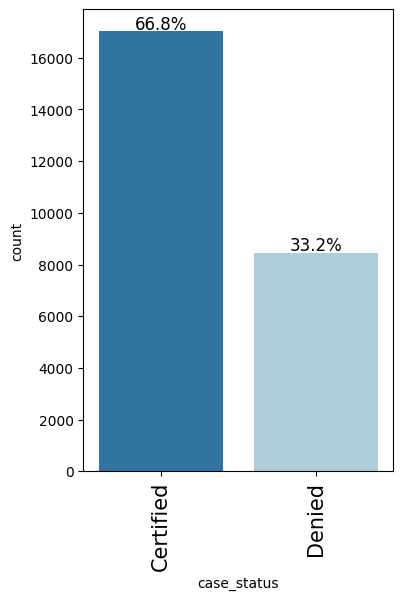

In [285]:
labeled_barplot(df, 'case_status',perc=True)

- **66.8%** of employees got their **Visa certified.**
- **33.2%** of employees got their **Visa denied.**

### Observations on continent

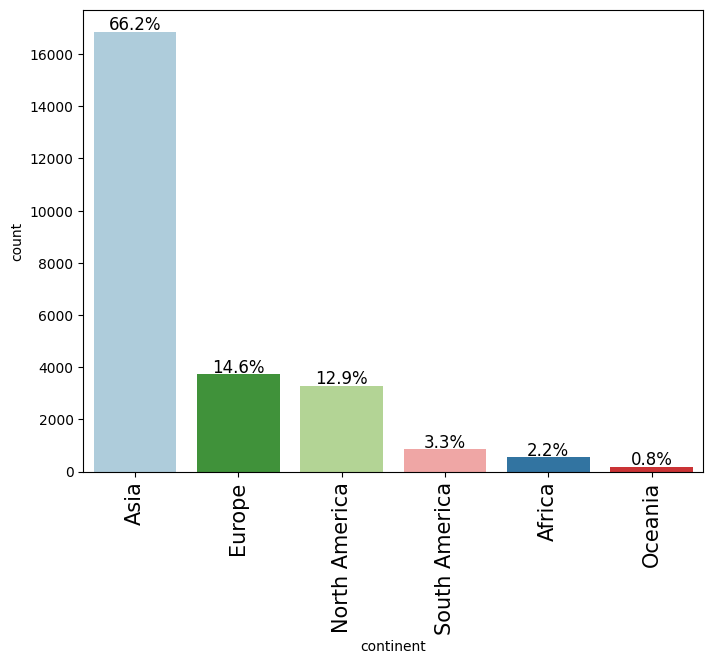

In [286]:
labeled_barplot(df, 'continent',perc=True)

- Most of the employees are from **Asia with 66.2%**.
- **14.6%** of employees are from **Europe**.
- **12.9%** of employees are from **North America**.
- **3.3%** of employees are from **South America**.
- **2.2%** of employees are from **Africa**.
- **0.8%** of employees are from **Oceania**.


### Observations of education

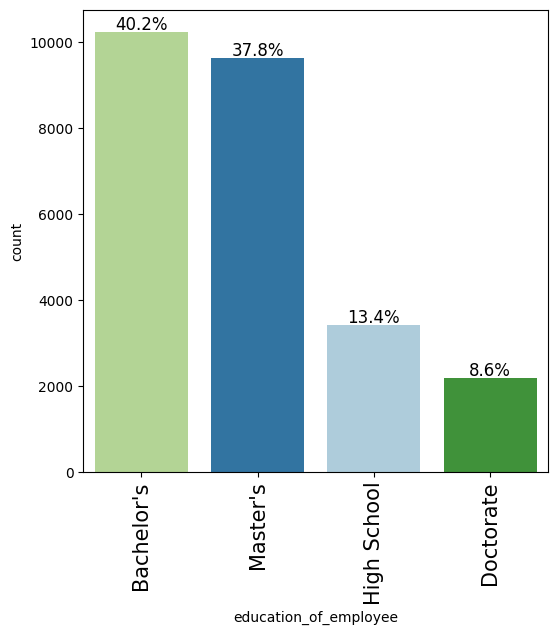

In [287]:
labeled_barplot(df, 'education_of_employee',perc=True)

- **40.2%** of employees have completed their **Bachelor's**.
- **37.8%** of employees have completed their **Master's**.
- **13.4%** of employees have completed thier **High School Education**.
- **8.6%** of employees have completed thier **Doctorate**.

### Observations on has_job_experience

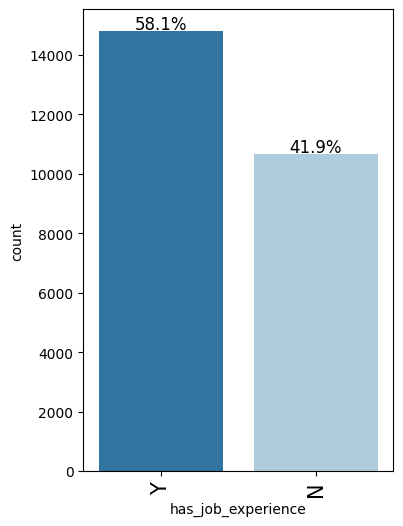

In [288]:
labeled_barplot(df, 'has_job_experience',perc=True)

- **58.1%** of employees have prior job experience.
- **41.9** of employees do not have prior job experience.

### Observations on requires_job_training

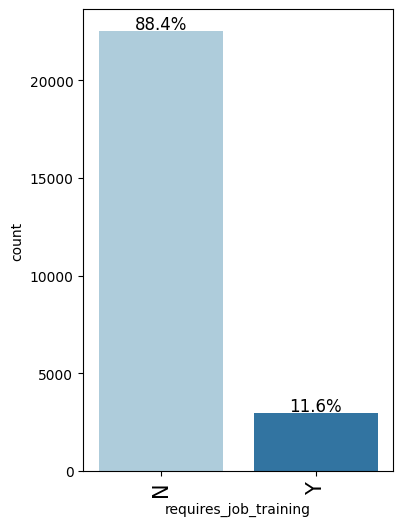

In [289]:
labeled_barplot(df, 'requires_job_training',perc=True)

- **88.4%** of employees requires job training.
- **11.6%** of employees do not require job training.

### Observations on no_of_employees

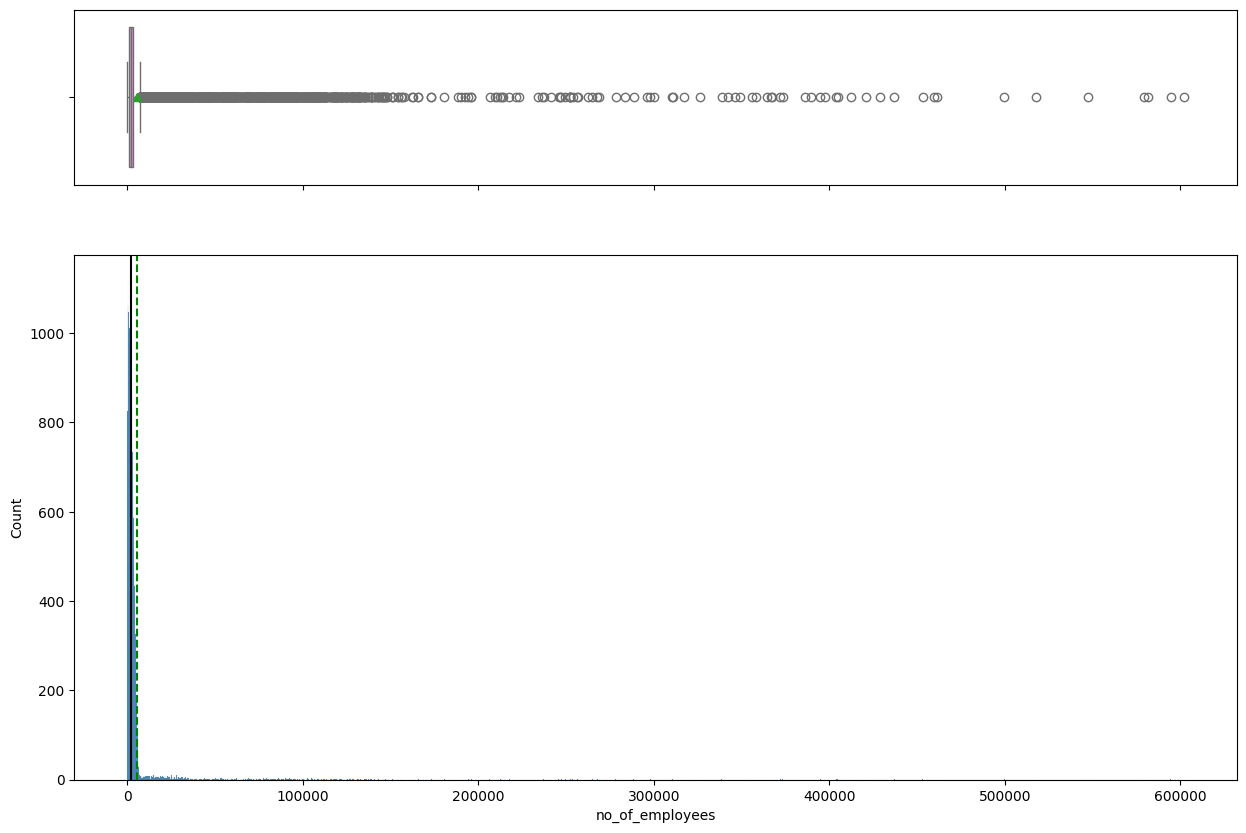

In [290]:
histogram_boxplot(df, 'no_of_employees')

- **602069** is the **maximum** number of employees working in a single company.
- **Average** number of employees working in each company is **5667**.
- The histogram of no_of_employees column is **right-skewed**.





### Observations on yr_of_estab

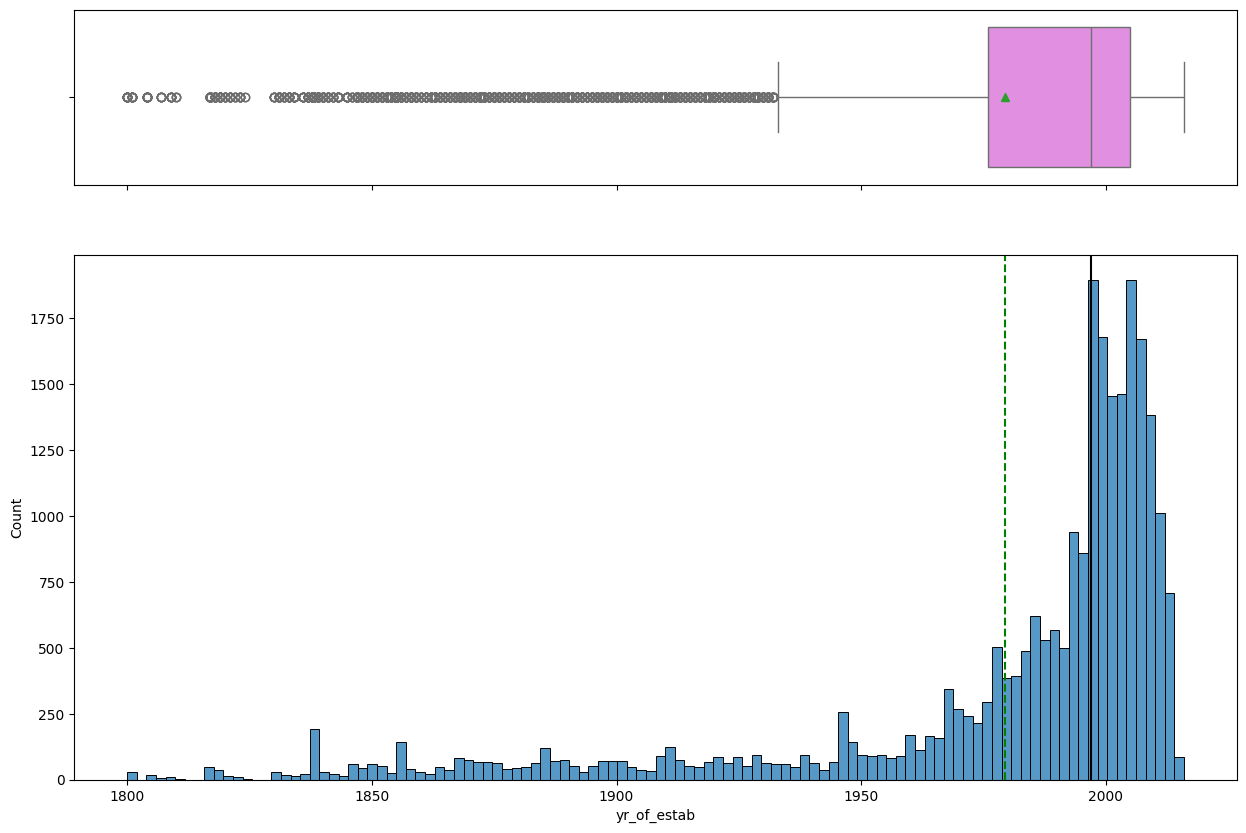

In [291]:
histogram_boxplot(df, 'yr_of_estab')

- Most of the companies are established in 1997.
- The histogram of yr_of_estab column is **left-skewed**.

### Observations on region_of_employment

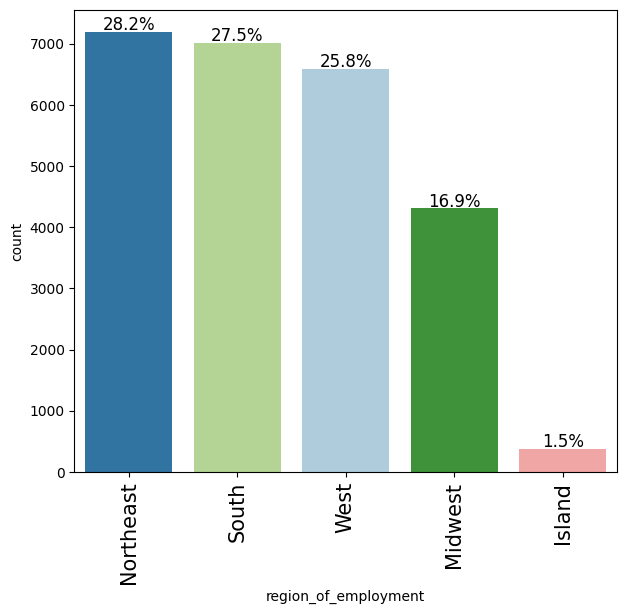

In [292]:
labeled_barplot(df, 'region_of_employment',perc=True)

- Most of the foregin workers are from **Northeast** with a percentage of **28.3%**.
- **27.5%** of foregin workers are from the **south**.
- **25.8%** of foregin workers are from **west**.
- **16.9%** of foregin workers are from **midwest**.
- **1.5%** of foregin workers are from **islands**.

### Observations on prevailing_wage

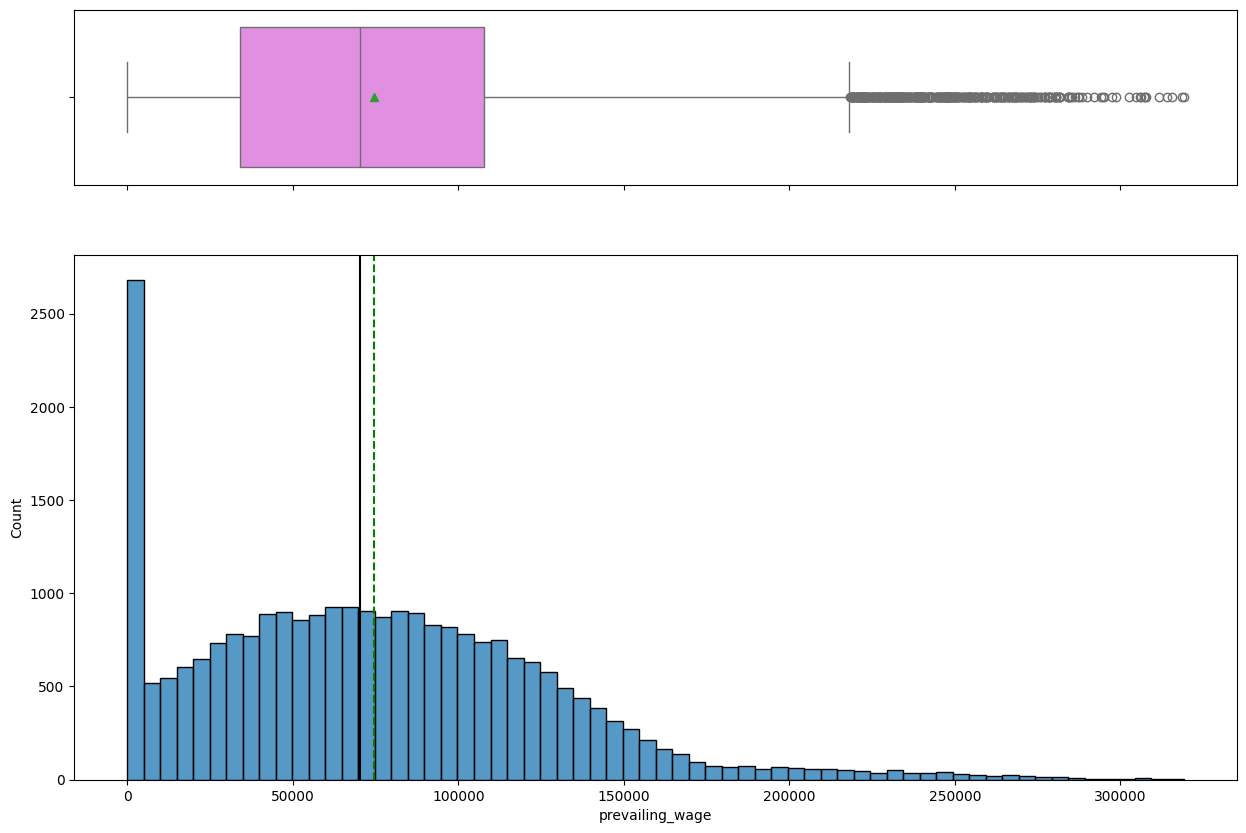

In [293]:
histogram_boxplot(df, 'prevailing_wage')

- Average wage paid to employees is **74455$**.

- Majority of employees are paid an average wage of **70308$**.

### Observations of unit_of_wage

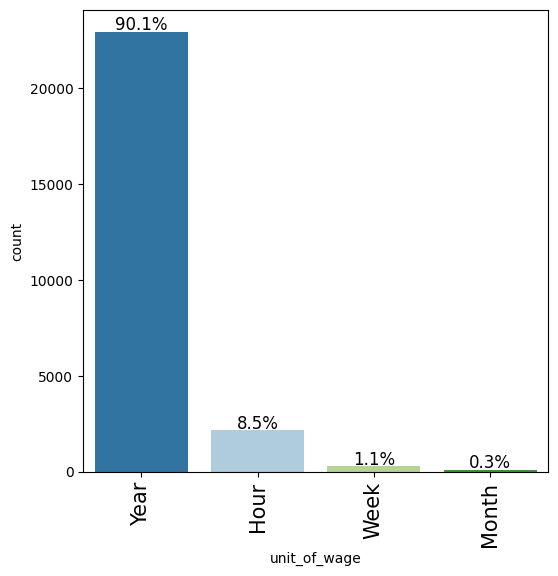

In [294]:
labeled_barplot(df, 'unit_of_wage',perc=True)

- Most of the employees are paid on **Yearly basis** with a percentage of **90.1%**.
- **8.5%** of employees are paid on **Hourly basis**.
- **1.1%** of employees are paid on **Weekly basis**.
- **0.3%** of employees are paid on Monthly basis**.

### Observations on full_time_position

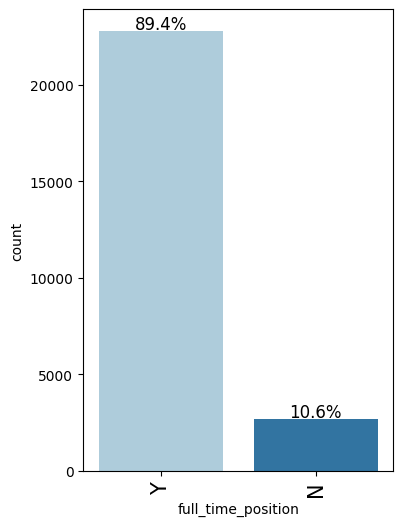

In [295]:
labeled_barplot(df, 'full_time_position',perc=True)

- **89.4%** of employees accuired full time positions.
- **10.6%** of employees did not accuire full time positions.

## Bivariate Analysis

### Observations between case-status and continent

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


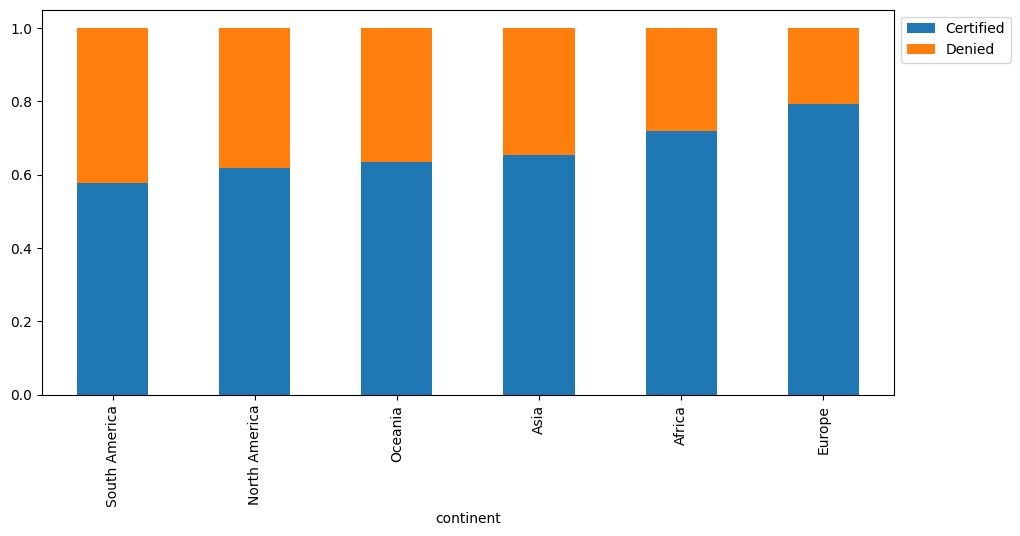

In [296]:
stacked_barplot(df, 'continent', 'case_status')

- **South Africa** has the most Visa denied applications.
- **Europe** has the most visa approved applications.


### Observations between education_of_employees and case_status

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


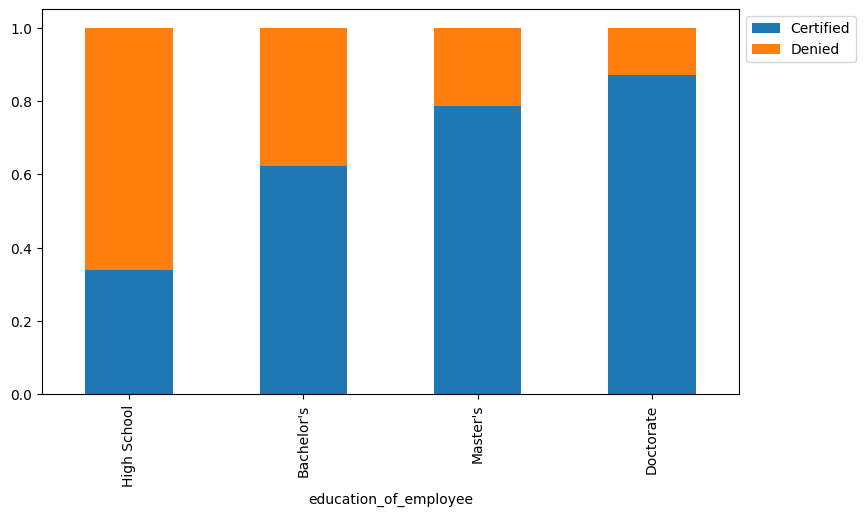

In [297]:
stacked_barplot(df, 'education_of_employee', 'case_status')

- Employees with **High school** graduation have **highest visa rejected applications**.
- Employees with **Doctorate** have **least visa rejection rate**.

### Observations between has_job_experience and case_status

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


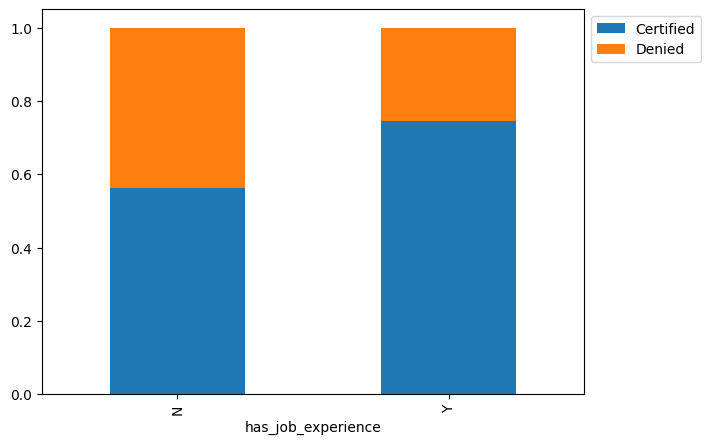

In [298]:
stacked_barplot(df, 'has_job_experience', 'case_status')

- Employees with job experience have least visa rejection rate.
- Employees without job experience have highest visa rejection rate.


### Observations between region_of_employment and case_status

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


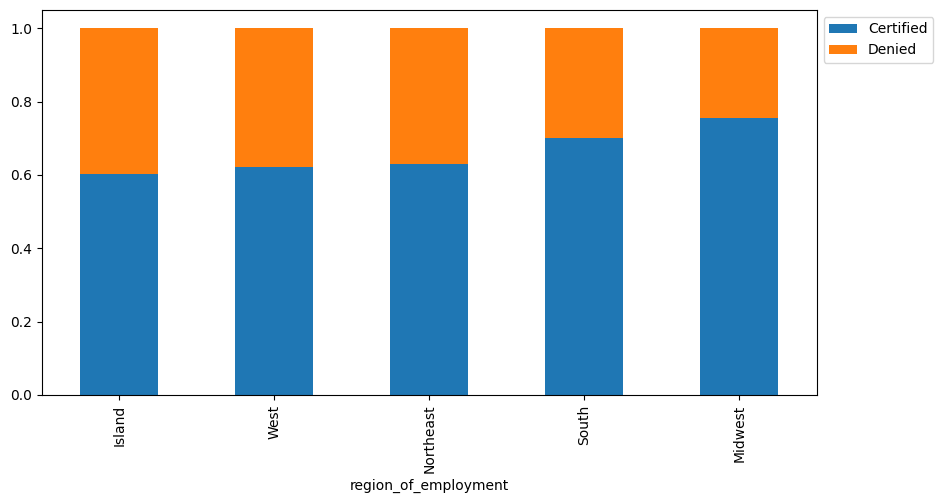

In [299]:
stacked_barplot(df, 'region_of_employment', 'case_status')

- Employees working in **islands** have highest visa rejection rate.
- Employees working in **Midwest** have least visa rejection rate.
- Employees working in **west** and **Northeast** have approximately same visa rejection rate

### Observations between unit_of_wage and case_status

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


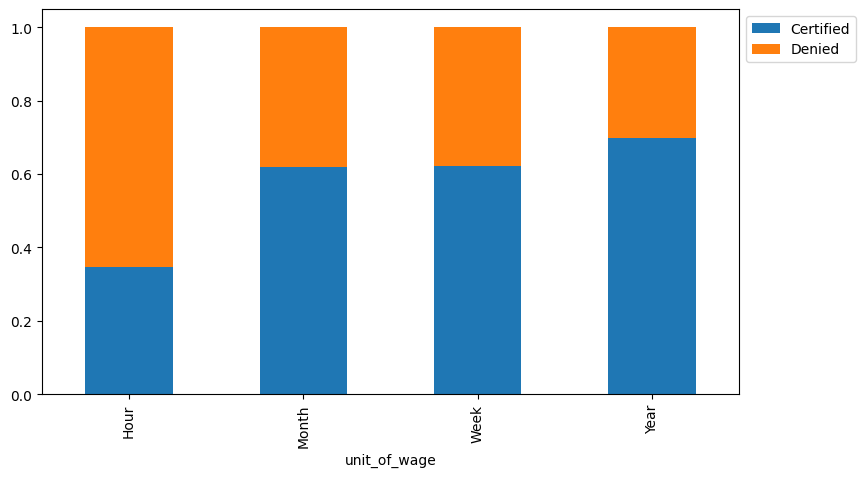

In [300]:
stacked_barplot(df, 'unit_of_wage', 'case_status')

- **Hourly wage** employees have highest visa rejection rate.
- **Yearly wage** employees have least visa rejection rate.

### Observations between no_of_employees and case_status

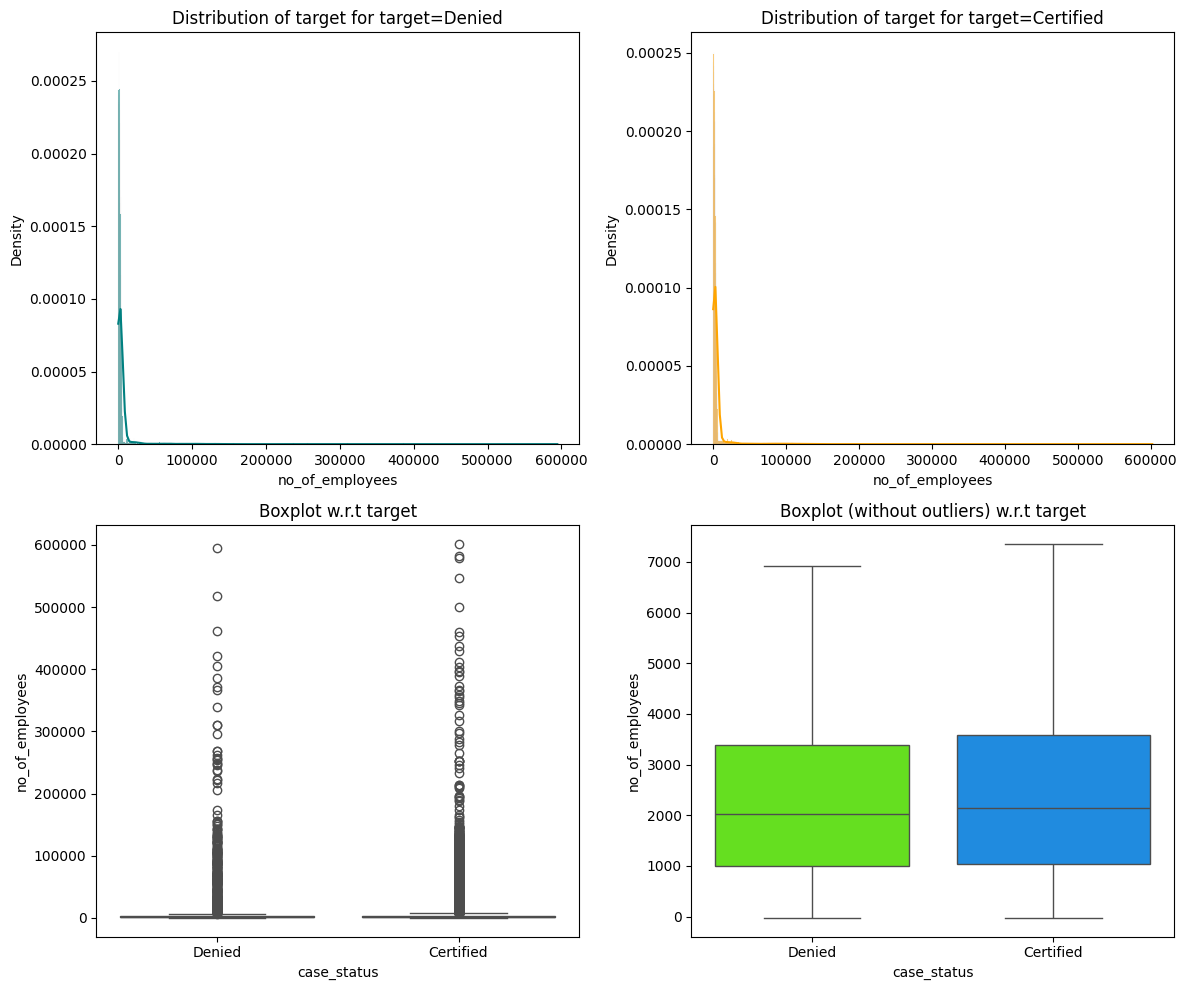

In [301]:
distribution_plot_wrt_target(df, 'no_of_employees', 'case_status')

- Majority of employees have their visa applications certified when compared to denied applications.

### Heatmap

<Axes: >

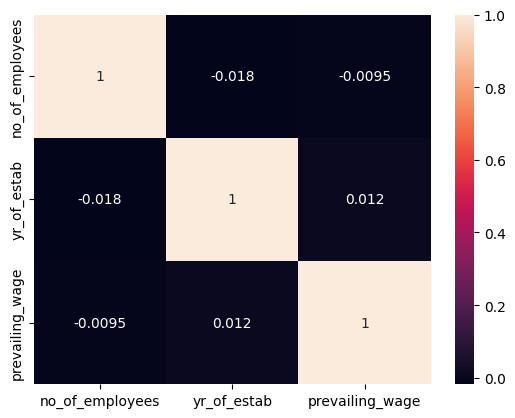

In [302]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

- we can see there is no strong correlation between numerical columns.

# Data Preprocessing

In [303]:
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


- There are no null values in the data.

In [304]:
df.duplicated().sum()

np.int64(0)

- There are no duplicate values in the data.

## Outliers Treatment


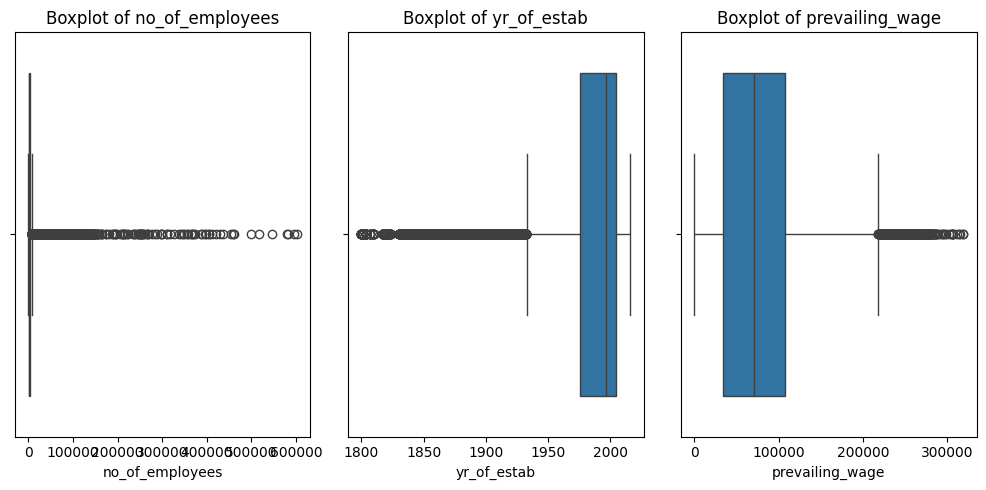

In [305]:
numeric_columns = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10, 5))
num_cols = len(numeric_columns)
rows = (num_cols + 2) // 3
for i, variable in enumerate(numeric_columns):
    plt.subplot(rows, 3, i + 1)
    sns.boxplot(data=df, x=variable)
    plt.title(f'Boxplot of {variable}')
plt.tight_layout()
plt.show()

- There are many numerical outliers in each numerical column but we cannot treat them because they are significant values that influence the target variable.

## Feature Engineering

In [306]:
df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


**We can drop case_id column as it does not contribute for prediction.

In [307]:
df = df.drop('case_id',axis=1)
df

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...
25475,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


### Treating no_of_employees column

- **we cannot have negative values in no_of_employees column**.

In [308]:
df[df['no_of_employees'] < 0]

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,Europe,Master's,N,N,-25,1980,Northeast,39452.9900,Year,Y,Certified
378,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.1400,Year,Y,Denied
832,South America,Master's,Y,N,-17,2002,South,129701.9400,Year,Y,Certified
2918,Asia,Master's,Y,N,-26,2005,Midwest,112799.4600,Year,Y,Certified
6439,Asia,Bachelor's,N,N,-14,2013,South,103.9700,Hour,Y,Denied
6634,Asia,Bachelor's,Y,N,-26,1923,West,5247.3200,Year,Y,Denied
7224,Europe,Doctorate,N,N,-25,1998,Midwest,141435.9500,Year,Y,Certified
7281,Asia,High School,N,N,-14,2000,Midwest,58488.5000,Year,Y,Denied
7318,Asia,Bachelor's,Y,Y,-26,2006,South,115005.6100,Year,Y,Certified
7761,Asia,Master's,N,N,-11,2009,Midwest,38457.5100,Year,Y,Certified


In [309]:
df.loc[df['no_of_employees'] < 0, 'no_of_employees'] = np.nan

In [310]:
df['no_of_employees'] = df['no_of_employees'].fillna(df['no_of_employees'].median())

In [311]:
replaceStruct = {'has_job_experience': {'N': 0, 'Y': 1},
                 'requires_job_training': {'N': 0, 'Y': 1},
                 'full_time_position': {'N': 0, 'Y': 1},
                 'case_status': {'Denied': 0, 'Certified': 1}}



In [312]:
oneHotCols = ['continent', 'education_of_employee', 'region_of_employment','unit_of_wage']

In [313]:
df=df.replace(replaceStruct)
df=pd.get_dummies(df, columns=oneHotCols,dtype='float')
df.head(10)


,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,prevailing_wage,full_time_position,case_status,continent_Africa,continent_Asia,continent_Europe,...,education_of_employee_Master's,region_of_employment_Island,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Hour,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year
0,0,0,14513.0,2007,592.2029,1,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,1,0,2412.0,2002,83425.6500,1,1,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,1,44444.0,2008,122996.8600,1,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0,0,98.0,1897,83434.0300,1,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1,0,1082.0,2005,149907.3900,1,1,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5,1,0,2339.0,2012,78252.1400,1,1,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
6,0,0,4985.0,1994,53635.3900,1,1,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
7,1,0,3035.0,1924,418.2298,1,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
8,0,0,4810.0,2012,74362.1900,1,1,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9,1,0,2251.0,1995,67514.7600,1,1,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [314]:
df.shape

(25480, 26)

In [315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 26 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   has_job_experience                 25480 non-null  int64  
 1   requires_job_training              25480 non-null  int64  
 2   no_of_employees                    25480 non-null  float64
 3   yr_of_estab                        25480 non-null  int64  
 4   prevailing_wage                    25480 non-null  float64
 5   full_time_position                 25480 non-null  int64  
 6   case_status                        25480 non-null  int64  
 7   continent_Africa                   25480 non-null  float64
 8   continent_Asia                     25480 non-null  float64
 9   continent_Europe                   25480 non-null  float64
 10  continent_North America            25480 non-null  float64
 11  continent_Oceania                  25480 non-null  flo

## Data splitting

In [316]:
X = df.drop('case_status',axis=1)
y = df['case_status']

In [317]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(14268, 25) (6116, 25) (5096, 25)


In [318]:
print('Number of rows and columns in train data =', X_train.shape)
print('Number of rows and columns in validation data =', X_val.shape)
print('Number of rows and columns in test data =', X_test.shape)

Number of rows and columns in train data = (14268, 25)
Number of rows and columns in validation data = (6116, 25)
Number of rows and columns in test data = (5096, 25)


# Model Building

In [319]:
def model_performance(model, predictors, target):
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)
    df_perf = pd.DataFrame(
        {'Accuracy': acc, 'Recall': recall, 'Precision': precision, 'F1': f1,},
        index=[0],
    )

    return df_perf

# Model Building - Original Data:

- **Recall score is considered as the appropriate metric for model evaluation**.

In [320]:
models = []
models.append(('Bagging', BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(('Random forest', RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(('GBM', GradientBoostingClassifier(random_state=1)))
models.append(('Adaboost', AdaBoostClassifier(random_state=1)))
models.append(('dtree', DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print('Training Performance:\n')
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print('{}: {}'.format(name, scores))

print('-'*50)
print('Validation Performance:\n')
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print('{}: {}'.format(name, scores_val))

Training Performance:

Bagging: 0.9845734074929163
Random forest: 1.0
GBM: 0.8834085423444223
Adaboost: 0.8919089096442439
dtree: 1.0
--------------------------------------------------
Validation Performance:

Bagging: 0.7858017135862914
Random forest: 0.8440636474908201
GBM: 0.8734394124847001
Adaboost: 0.8849449204406364
dtree: 0.7571603427172583


In [321]:
print('Training and Validation Performance Difference:\n')

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print('{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}'.format(name, scores_train, scores_val, difference1))

Training and Validation Performance Difference:

Bagging: Training Score: 0.9846, Validation Score: 0.7858, Difference: 0.1988
Random forest: Training Score: 1.0000, Validation Score: 0.8441, Difference: 0.1559
GBM: Training Score: 0.8834, Validation Score: 0.8734, Difference: 0.0100
Adaboost: Training Score: 0.8919, Validation Score: 0.8849, Difference: 0.0070
dtree: Training Score: 1.0000, Validation Score: 0.7572, Difference: 0.2428


- **Adaboost** has the best performance followed by **GBM** model as per the **validation performance**.

# Model Building - Oversampled Data

In [322]:
print('Before Oversampling, counts of Visa applications Certified: {}'.format(sum(y_train == 1)))
print('Before Oversampling, counts of Visa applications Denied: {} \n'.format(sum(y_train == 0)))
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)
print('After Oversampling, counts of Visa applications Certified: {}'.format(sum(y_train_over == 1)))
print('After Oversampling, counts of Visa applications Denied: {} \n'.format(sum(y_train_over == 0)))
print('After Oversampling, the shape of X_train: {}'.format(X_train_over.shape))
print('After Oversampling, the shape of y_train: {} '.format(y_train_over.shape))

Before Oversampling, counts of Visa applications Certified: 9529
Before Oversampling, counts of Visa applications Denied: 4739 

After Oversampling, counts of Visa applications Certified: 9529
After Oversampling, counts of Visa applications Denied: 9529 

After Oversampling, the shape of X_train: (19058, 25)
After Oversampling, the shape of y_train: (19058,) 


In [323]:
models = []
models.append(('Bagging', BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(('Random forest', RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(('GBM', GradientBoostingClassifier(random_state=1)))
models.append(('Adaboost', AdaBoostClassifier(random_state=1)))
models.append(('dtree', DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print('Training Performance:\n')
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))
    print('{}: {}'.format(name, scores))

print('-'*50)
print('Validation Performance:\n')
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_val = recall_score(y_val, model.predict(X_val))
    print('{}: {}'.format(name, scores_val))

Training Performance:

Bagging: 0.9831042082065274
Random forest: 1.0
GBM: 0.8586420400881519
Adaboost: 0.8547591562598383
dtree: 1.0
--------------------------------------------------
Validation Performance:

Bagging: 0.7725826193390453
Random forest: 0.824969400244798
GBM: 0.8460220318237454
Adaboost: 0.8425948592411261
dtree: 0.7380660954712362


In [324]:
print('Training and Validation Performance Difference:\n')

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print('{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}'.format(name, scores_train, scores_val, difference2))

Training and Validation Performance Difference:

Bagging: Training Score: 0.9831, Validation Score: 0.7726, Difference: 0.2105
Random forest: Training Score: 1.0000, Validation Score: 0.8250, Difference: 0.1750
GBM: Training Score: 0.8586, Validation Score: 0.8460, Difference: 0.0126
Adaboost: Training Score: 0.8548, Validation Score: 0.8426, Difference: 0.0122
dtree: Training Score: 1.0000, Validation Score: 0.7381, Difference: 0.2619


- **GBM** has the best performance followed by **AdaBoost** model as per the **validation performance**.

# Model Building - Undersampled Data

In [325]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [326]:
print('Before Undersampling, counts of Visa applications Certified: {}'.format(sum(y_train == 1)))
print('Before Undersampling, counts of Visa applications Denied: {} \n'.format(sum(y_train == 0)))


print('After Undersampling, counts of Visa applications Certified: {}'.format(sum(y_train_un == 1)))
print('After Undersampling, counts of Visa applications Denied: {} \n'.format(sum(y_train_un == 0)))


print('After Undersampling, the shape of X_train: {}'.format(X_train_un.shape))
print('After Undersampling, the shape of y_train: {} '.format(y_train_un.shape))

Before Undersampling, counts of Visa applications Certified: 9529
Before Undersampling, counts of Visa applications Denied: 4739 

After Undersampling, counts of Visa applications Certified: 4739
After Undersampling, counts of Visa applications Denied: 4739 

After Undersampling, the shape of X_train: (9478, 25)
After Undersampling, the shape of y_train: (9478,) 


In [327]:
models = []
models.append(('Bagging', BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(('Random forest', RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(('GBM', GradientBoostingClassifier(random_state=1)))
models.append(('Adaboost', AdaBoostClassifier(random_state=1)))
models.append(('dtree', DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print('Training Performance:\n')
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))
    print('{}: {}'.format(name, scores))

print('-'*50)
print('Validation Performance:\n')
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_val = recall_score(y_val, model.predict(X_val))
    print('{}: {}'.format(name, scores_val))

Training Performance:

Bagging: 0.9662376028698038
Random forest: 0.9997889850179362
GBM: 0.7387634522051065
Adaboost: 0.7113315045368221
dtree: 1.0
--------------------------------------------------
Validation Performance:

Bagging: 0.617625458996328
Random forest: 0.6682986536107711
GBM: 0.7238678090575276
Adaboost: 0.7126070991432069
dtree: 0.616891064871481


In [328]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = recall_score(y_train_un, model.predict(X_train_un))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9662, Validation Score: 0.6176, Difference: 0.3486
Random forest: Training Score: 0.9998, Validation Score: 0.6683, Difference: 0.3315
GBM: Training Score: 0.7388, Validation Score: 0.7239, Difference: 0.0149
Adaboost: Training Score: 0.7113, Validation Score: 0.7126, Difference: -0.0013
dtree: Training Score: 1.0000, Validation Score: 0.6169, Difference: 0.3831


- **GBM** has the best performance followed by **AdaBoost** model as per the **validation performance**.

- After building 15 models, we observed that both the GBM and Adaboost models, trained on an undersampled and oversampled dataset shows good performance on both the training and validation datasets.


# Hyperparameter Tuning

## Tuning AdaBoostClassifier model with Undersampled data

### Finding Best parameters

In [329]:
from sklearn import metrics
from sklearn.model_selection import RandomizedSearchCV

Model = AdaBoostClassifier(random_state=1)
param_grid = {
    'n_estimators': np.arange(10, 40, 10),
    'learning_rate': [0.1, 0.01, 0.2, 0.05, 1],
    'estimator': [DecisionTreeClassifier(max_depth=1, random_state=1),
                  DecisionTreeClassifier(max_depth=2, random_state=1),
                  DecisionTreeClassifier(max_depth=3, random_state=1)]}
scorer = metrics.make_scorer(metrics.recall_score)
random_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)
random_cv.fit(X_train_un, y_train_un)


RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'estimator': [DecisionTreeClassifier(max_depth=1,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=2,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=3,
                                                                             random_state=1)],
                                        'learning_rate': [0.1, 0.01, 0.2, 0.05,
                                                          1],
                                        'n_estimators': array([10, 20, 30])},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [330]:
print('Best parameters:\n', random_cv.best_params_)

Best parameters:
 {'n_estimators': np.int64(10), 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)}


In [331]:
print('CV score of best parameters:\n', random_cv.best_score_)

CV score of best parameters:
 0.9320523616661989


### Model tuning with best parameters

In [332]:
tuned_adb_un = AdaBoostClassifier(random_state=1,n_estimators=10,learning_rate=0.1,estimator=DecisionTreeClassifier(max_depth=1, random_state=1))
tuned_adb_un.fit(X_train_un, y_train_un)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=10, random_state=1)

### Training performace of model with best parameters

In [333]:
train_perf = model_performance(tuned_adb_un, X_train_un, y_train_un)
train_perf

,Accuracy,Recall,Precision,F1
0,0.600443,0.932053,0.560391,0.699945


Text(0.5, 14.722222222222216, 'Predicted label')

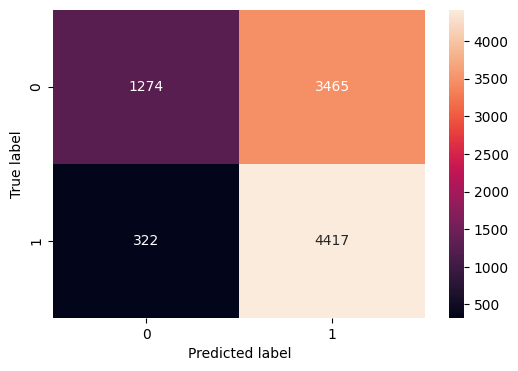

In [334]:
y_pred_un = tuned_adb_un.predict(X_train_un)
cm = confusion_matrix(y_train_un,y_pred_un)


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='')
plt.ylabel('True label')
plt.xlabel('Predicted label')

- Model performs well on training set with recall score of 93.2%.

### Validation performance of model with best parameters

In [335]:
val_perf = model_performance(tuned_adb_un, X_val, y_val)
val_perf

,Accuracy,Recall,Precision,F1
0,0.711086,0.932681,0.718597,0.811761


Text(0.5, 14.722222222222216, 'Predicted label')

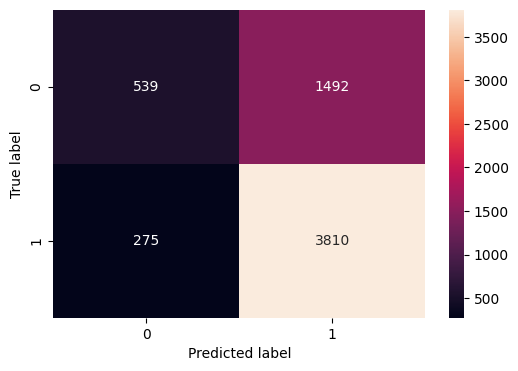

In [336]:
y_pred_val_un = tuned_adb_un.predict(X_val)
cm = confusion_matrix(y_val,y_pred_val_un)


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='')
plt.ylabel('True label')
plt.xlabel('Predicted label')

- Model performs well on validation set with recall score of 93.26%.


## Tuning Gradient Boosting model with Undersampled Data

### Finding Best parameters

In [337]:
Model = GradientBoostingClassifier(random_state=1)
param_grid = {
    'init': [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    'n_estimators': np.arange(125,175,25),
    'learning_rate': [0.01, 0.2, 0.05, 1],
    'subsample':[0.8,0.9,1],
    'max_features':[0.5,0.7,1]}
scorer = metrics.make_scorer(metrics.recall_score)
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)
randomized_cv.fit(X_train_un,y_train_un)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'init': [AdaBoostClassifier(random_state=1),
                                                 DecisionTreeClassifier(random_state=1)],
                                        'learning_rate': [0.01, 0.2, 0.05, 1],
                                        'max_features': [0.5, 0.7, 1],
                                        'n_estimators': array([125, 150]),
                                        'subsample': [0.8, 0.9, 1]},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [338]:
print('Best parameters:\n', randomized_cv.best_params_)

Best parameters:
 {'subsample': 1, 'n_estimators': np.int64(150), 'max_features': 0.5, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)}


In [339]:
print('CV score of best parameters:\n',randomized_cv.best_score_)

CV score of best parameters:
 0.7455119208337232


### Model tuning with best parameters

In [340]:
tuned_gbm_un = GradientBoostingClassifier(random_state=1,subsample=1,n_estimators=150,max_features=0.5,learning_rate=0.01,init=AdaBoostClassifier(random_state=1))
tuned_gbm_un.fit(X_train_un, y_train_un)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=0.5,
                           n_estimators=150, random_state=1, subsample=1)

### Training performace of model with best parameters

In [341]:
gbm_un_train = model_performance(tuned_gbm_un, X_train_un, y_train_un)
gbm_un_train

,Accuracy,Recall,Precision,F1
0,0.708377,0.748048,0.69306,0.719505


Text(0.5, 14.722222222222216, 'Predicted label')

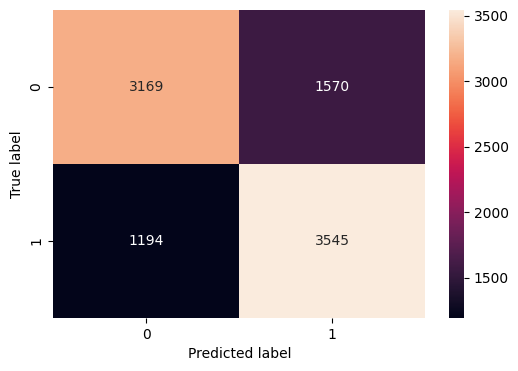

In [342]:
y_pred_un = tuned_gbm_un.predict(X_train_un)
cm = confusion_matrix(y_train_un,y_pred_un)


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='')
plt.ylabel('True label')
plt.xlabel('Predicted label')

- Model performs decently on training set with recall score of **74.8%**.

### Validation performance of model with best parameters

In [343]:
gbm_un_val = model_performance(tuned_gbm_un, X_val, y_val)
gbm_un_val


,Accuracy,Recall,Precision,F1
0,0.718934,0.744186,0.818525,0.779587


Text(0.5, 14.722222222222216, 'Predicted label')

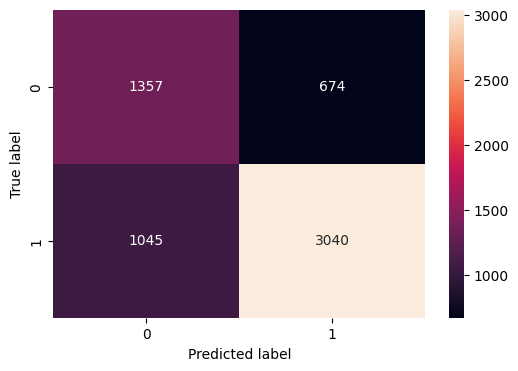

In [344]:
y_pred_val_un = tuned_gbm_un.predict(X_val)
cm = confusion_matrix(y_val,y_pred_val_un)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='')
plt.ylabel('True label')
plt.xlabel('Predicted label')

- Model performs decently on validation set with recall score of **74.4%**.

## Tuning Adaboosting model with Oversampled data

### Finding Best parameters

In [345]:
Model = AdaBoostClassifier(random_state=1)
param_grid = {
    'n_estimators': np.arange(10, 60, 10),
    'learning_rate': [0.1, 0.01, 0.2, 0.05, 1],
    'estimator': [DecisionTreeClassifier(max_depth=1, random_state=1),
                  DecisionTreeClassifier(max_depth=2, random_state=1),
                  DecisionTreeClassifier(max_depth=3, random_state=1),
                  DecisionTreeClassifier(max_depth=4, random_state=1),
                  DecisionTreeClassifier(max_depth=5, random_state=1)]}
scorer = metrics.make_scorer(metrics.recall_score)
random_cv_1 = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)
random_cv_1.fit(X_train_over, y_train_over)


RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'estimator': [DecisionTreeClassifier(max_depth=1,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=2,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=3,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=4,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=5,
                                                                             random_state=1)],
                                        'learning_rate': [0.1, 0.01, 0.2, 0.05,
                                                          1],
                                        'n_estimators': array([10, 20, 30, 40, 50])},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [346]:
print('Best parameters:\n', random_cv_1.best_params_)

Best parameters:
 {'n_estimators': np.int64(40), 'learning_rate': 0.01, 'estimator': DecisionTreeClassifier(max_depth=4, random_state=1)}


In [347]:
print('CV score of best parameters:\n', random_cv_1.best_score_)

CV score of best parameters:
 0.8619982208414922


### Model tuning with best parameters

In [348]:
tuned_adb_over = AdaBoostClassifier(random_state=1,n_estimators=40,learning_rate=0.01,estimator=DecisionTreeClassifier(max_depth=4, random_state=1))
tuned_adb_over.fit(X_train_over, y_train_over)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=4,
                                                    random_state=1),
                   learning_rate=0.01, n_estimators=40, random_state=1)

### Training performace of model with best parameters

In [349]:
adb_over_train = model_performance(tuned_adb_over, X_train_over, y_train_over)
adb_over_train

,Accuracy,Recall,Precision,F1
0,0.767184,0.846679,0.730532,0.784329


Text(0.5, 14.722222222222216, 'Predicted label')

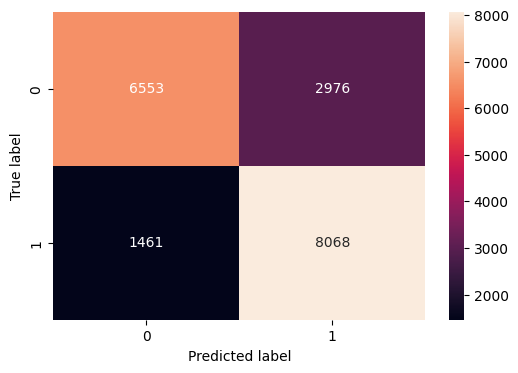

In [350]:
y_pred_over = tuned_adb_over.predict(X_train_over)
cm = confusion_matrix(y_train_over,y_pred_over)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g')
plt.ylabel('True label')
plt.xlabel('Predicted label')

- Model performs well on training set with recall score of 84.66%.

### Validation performance of model with best parameters

In [351]:
adb_over_val = model_performance(tuned_adb_over, X_val, y_val)
adb_over_val

,Accuracy,Recall,Precision,F1
0,0.724984,0.840392,0.769214,0.803229


Text(0.5, 14.722222222222216, 'Predicted label')

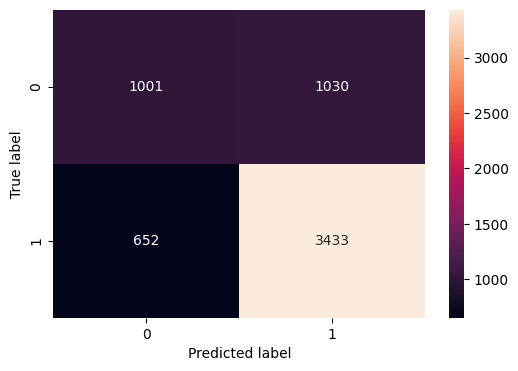

In [352]:
y_pred_val_over = tuned_adb_over.predict(X_val)
cm = confusion_matrix(y_val,y_pred_val_over)


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='')
plt.ylabel('True label')
plt.xlabel('Predicted label')

Model performs well on validation set with recall score of 84.03%.

## Tuning Gradient Boosting model with Oversampled data

### Finding Best parameters

In [353]:
Model = GradientBoostingClassifier(random_state=1)
param_grid = {
    'init': [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    'n_estimators': np.arange(75,150,25),
    'learning_rate': [0.1, 0.01, 0.2, 0.05, 1],
    'subsample':[0.5,0.7,1],
    'max_features':[0.5,0.7,1]}
scorer = metrics.make_scorer(metrics.recall_score)
randomized_cv_1 = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)
randomized_cv_1.fit(X_train_over, y_train_over)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'init': [AdaBoostClassifier(random_state=1),
                                                 DecisionTreeClassifier(random_state=1)],
                                        'learning_rate': [0.1, 0.01, 0.2, 0.05,
                                                          1],
                                        'max_features': [0.5, 0.7, 1],
                                        'n_estimators': array([ 75, 100, 125]),
                                        'subsample': [0.5, 0.7, 1]},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [354]:
print('Best parameters:\n', randomized_cv_1.best_params_)

Best parameters:
 {'subsample': 0.5, 'n_estimators': np.int64(125), 'max_features': 1, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)}


In [355]:
print('CV score of best parameters:\n',randomized_cv_1.best_score_)

CV score of best parameters:
 0.8699728168816254


### Model tuning with best parameters



In [356]:
tuned_gbm_over = GradientBoostingClassifier(random_state=1,subsample=0.5,n_estimators=125,max_features=1,learning_rate=0.01,init=AdaBoostClassifier(random_state=1))
tuned_gbm_over.fit(X_train_over, y_train_over)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=1, n_estimators=125,
                           random_state=1, subsample=0.5)

### Training performace of model with best parameters

In [357]:
gbm_over_train = model_performance(tuned_gbm_over, X_train_over, y_train_over)
gbm_over_train

,Accuracy,Recall,Precision,F1
0,0.796463,0.873859,0.756725,0.811085


Text(0.5, 14.722222222222216, 'Predicted label')

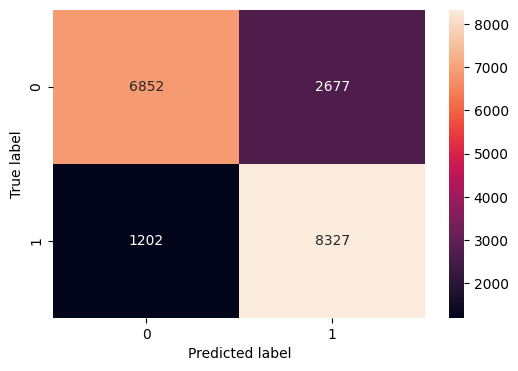

In [358]:
y_pred_over = tuned_gbm_over.predict(X_train_over)
cm = confusion_matrix(y_train_over,y_pred_over)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g')
plt.ylabel('True label')
plt.xlabel('Predicted label')

- Model performs well on training set with recall score of 87.38%.

### Validation performance of model with best parameters

In [359]:
gbm_over_val = model_performance(tuned_gbm_over, X_val, y_val)
gbm_over_val

,Accuracy,Recall,Precision,F1
0,0.730216,0.864627,0.763016,0.81065


Text(0.5, 14.722222222222216, 'Predicted label')

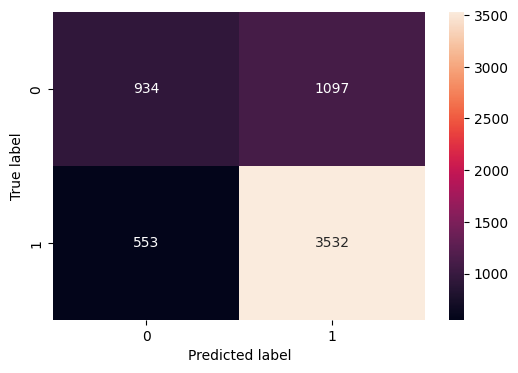

In [360]:
y_pred_val_over = tuned_gbm_over.predict(X_val)
cm = confusion_matrix(y_val,y_pred_val_over)


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='')
plt.ylabel('True label')
plt.xlabel('Predicted label')

- Model performs well on validation set with recall score of 86.46%.

# Model Comparison and Final Model Selection

## Training performance comparison

In [361]:
models_train_comp_df = pd.concat(
    [
        train_perf.T,
        gbm_un_train.T,
        adb_over_train.T,
        gbm_over_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    'AdaBoost trained with Undersampled data',
    'Gradient boosting trained with Undersampled data',
    'AdaBoost trained with Oversampled data',
    'Gradient boosting trained with Oversampled data',

]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,AdaBoost trained with Undersampled data,Gradient boosting trained with Undersampled data,AdaBoost trained with Oversampled data,Gradient boosting trained with Oversampled data
Accuracy,0.600443,0.708377,0.767184,0.796463
Recall,0.932053,0.748048,0.846679,0.873859
Precision,0.560391,0.693060,0.730532,0.756725
F1,0.699945,0.719505,0.784329,0.811085


## Validation performance comparison

In [362]:
models_val_comp_df = pd.concat(
    [
        val_perf.T,
        gbm_un_val.T,
        adb_over_val.T,
        gbm_over_val.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    'AdaBoost trained with Undersampled data',
    'Gradient boosting trained with Undersampled data',
    'AdaBoost trained with Oversampled data',
    'Gradient boosting trained with Oversampled data',

]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,AdaBoost trained with Undersampled data,Gradient boosting trained with Undersampled data,AdaBoost trained with Oversampled data,Gradient boosting trained with Oversampled data
Accuracy,0.711086,0.718934,0.724984,0.730216
Recall,0.932681,0.744186,0.840392,0.864627
Precision,0.718597,0.818525,0.769214,0.763016
F1,0.811761,0.779587,0.803229,0.810650


- AdaBoost model trained with undersampled data has generalised performance, so let's consider it as the best model.

## Feature Importance

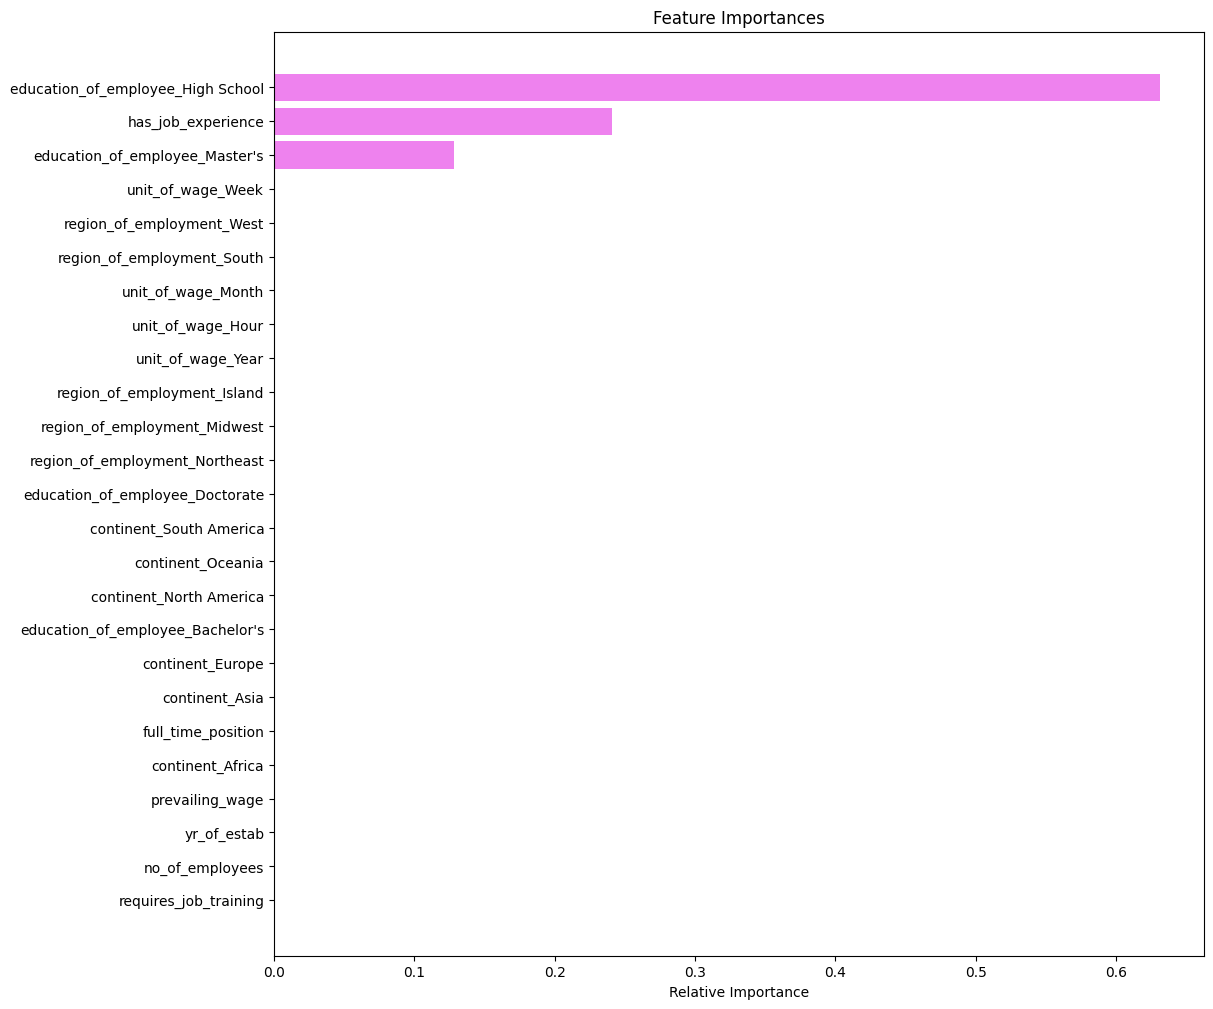

In [363]:
feature_names = X_train.columns
importances = tuned_adb_un.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- We can see that **has_job_experience, education_of_employee_High School, education_of_employee_master's** are the most important features for making predictions.

## Performance on test set

In [364]:
adb_test = model_performance(tuned_adb_un, X_test, y_test)
adb_test

,Accuracy,Recall,Precision,F1
0,0.708203,0.930082,0.717101,0.809822


Text(0.5, 14.722222222222216, 'Predicted label')

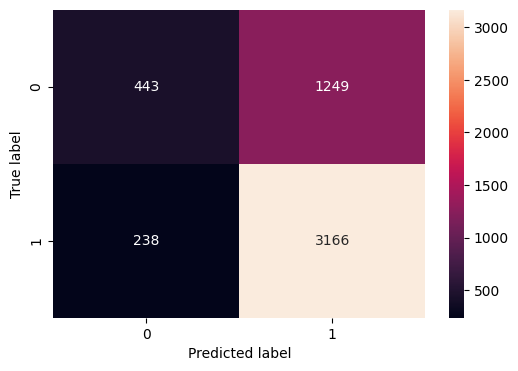

In [365]:
y_pred_un = tuned_adb_un.predict(X_test)
cm = confusion_matrix(y_test,y_pred_un)


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='')
plt.ylabel('True label')
plt.xlabel('Predicted label')


- The Adaboost model trained on undersampled data has given ~76% recall on the test set.

- So, this is a generalized model.